In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle

from scripts.simulation.sequence import simulate_sequences, downsample_sequences
import scripts.simulation.rank_correlation as rs 
from scripts.simulation.correlation_mean import add_within_clust_score
nrm = np.load("scripts/simulation/nrm.npy")

In [193]:
# PARAMETERS
params = {
    "n_neurons": 100000,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "sigma_range": (1,1),    # increasing range makes sequences less similar
    "vol_param": (0.1, 0.5),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": False,
    "rho_vol": 0.0,
    "shuffle_order": False,       # shuffle order of sequences
}

In [180]:
with open(f'50seed_orig_zscore_100_{params["sigma_range"]}_{params["vol_param"]}_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores_orig = pickle.load(f)

with open(f'50seed_downsampled_zscore_100000_{params["sigma_range"]}_{params["vol_param"]}_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores = pickle.load(f)

with open(f'50seed_orig_zscore_100_(0.02, 0.4)_{params["vol_param"]}_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores_orig_002 = pickle.load(f)

with open(f'50seed_downsampled_zscore_100000_(0.02, 0.4)_{params["vol_param"]}_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores_002 = pickle.load(f)

with open(f'50seed_orig_zscore_100_{params["sigma_range"]}_(0.07, 0.5)_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores_orig_05 = pickle.load(f)

with open(f'50seed_downsampled_zscore_100000_{params["sigma_range"]}_(0.07, 0.5)_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores_05 = pickle.load(f)

with open(f'50seed_orig_zscore_100_{params["sigma_range"]}_(0.1, 0.5)_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores_orig_0105 = pickle.load(f)

with open(f'50seed_downsampled_zscore_100000_{params["sigma_range"]}_(0.1, 0.5)_{params["rho_vol"]}.pkl', 'rb') as f:
    all_scores_0105 = pickle.load(f)

In [181]:
def flatten_scores(scores):
    numeric_vals = []

    def collect_numeric(x):
        if isinstance(x, dict):
            for v in x.values():
                collect_numeric(v)
            return

        if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
            # Flatten one container level and recurse to handle nested dict/list structures.
            arr = np.asarray(list(x) if isinstance(x, set) else x, dtype=object).reshape(-1)
            for item in arr:
                collect_numeric(item)
            return

        try:
            numeric_vals.append(float(x))
        except (TypeError, ValueError):
            # Skip non-numeric values if present in nested metadata.
            pass

    collect_numeric(scores)
    arr = np.asarray(numeric_vals, dtype=float)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

all_scores_orig_flat = flatten_scores(all_scores_orig)
all_scores_flat = flatten_scores(all_scores)
all_scores_orig_05_flat = flatten_scores(all_scores_orig_05)
all_scores_05_flat = flatten_scores(all_scores_05)
all_scores_orig_0105_flat = flatten_scores(all_scores_orig_0105)
all_scores_0105_flat = flatten_scores(all_scores_0105)


df = pd.DataFrame({
    'Mean Z-scores': np.concatenate([all_scores_orig_flat, all_scores_flat]),
    'Dataset': ['Original'] * len(all_scores_orig_flat) + ['Downsampled'] * len(all_scores_flat)
})

df_05 = pd.DataFrame({
    'Mean Z-scores': np.concatenate([all_scores_orig_05_flat, all_scores_05_flat]),
    'Dataset': ['Original'] * len(all_scores_orig_05_flat) + ['Downsampled'] * len(all_scores_05_flat)
})

df_0105 = pd.DataFrame({
    'Mean Z-scores': np.concatenate([all_scores_orig_0105_flat, all_scores_0105_flat]),
    'Dataset': ['Original'] * len(all_scores_orig_0105_flat) + ['Downsampled'] * len(all_scores_0105_flat)
})

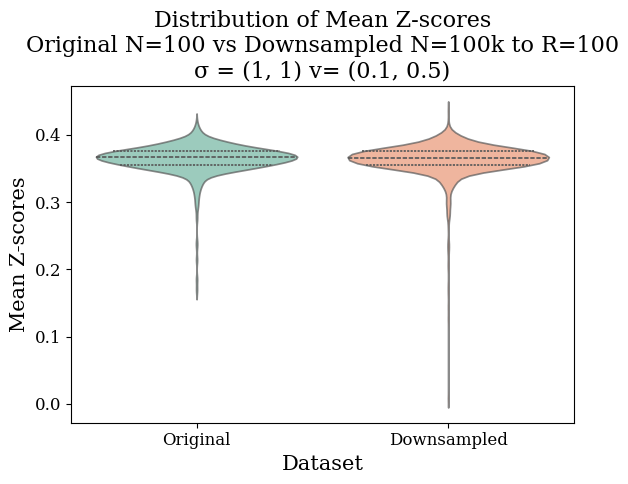

In [184]:
plt.figure(figsize=(6, 5))
sns.violinplot( 
    x = 'Dataset',
    y='Mean Z-scores', 
    hue='Dataset', 
    data=df_0105, 
    inner='quartile',
    palette='Set2',
    density_norm='count',
    alpha = 0.7,
    legend= False,
)

plt.ylabel('Mean Z-scores',fontsize=15)
plt.xlabel('Dataset',fontsize=15)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)

plt.title(f'Distribution of Mean Z-scores\nOriginal N=100 vs Downsampled N=100k to R=100\nσ = {params["sigma_range"]} v= {params["vol_param"]}', fontsize=16)
plt.tight_layout()
plt.savefig(f'50seed_zscore_comparison_violin1_{params["n_neurons"]}_{params["sigma_range"]}_{params["vol_param"]}_{params["rho_vol"]}.jpg', dpi=300)
plt.savefig(f'50seed_zscore_comparison_violin1_{params["n_neurons"]}_{params["sigma_range"]}_{params["vol_param"]}_{params["rho_vol"]}.pdf', dpi=300)
plt.show()

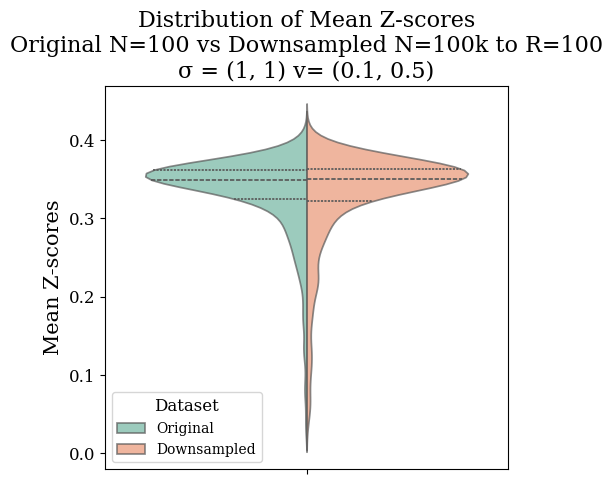

In [185]:
plt.figure(figsize=(5, 5))
sns.violinplot(
    y='Mean Z-scores', 
    hue='Dataset', 
    data=df_05, 
    split=True, 
    palette='Set2',
    alpha = 0.7,
    density_norm='count',
    inner='quartile'
)

plt.ylabel('Mean Z-scores',fontsize=15)
plt.tick_params(axis='y', labelsize=12)

plt.title(f'Distribution of Mean Z-scores\nOriginal N=100 vs Downsampled N=100k to R=100\nσ = {params["sigma_range"]} v= {params["vol_param"]}', fontsize=16)
plt.tight_layout()
plt.savefig(f'50seed_zscore_comparison_violin2_{params["n_neurons"]}_{params["sigma_range"]}_{params["vol_param"]}_{params["rho_vol"]}.jpg', dpi=300)
plt.savefig(f'50seed_zscore_comparison_violin2_{params["n_neurons"]}_{params["sigma_range"]}_{params["vol_param"]}_{params["rho_vol"]}.pdf', dpi=300)
plt.show()

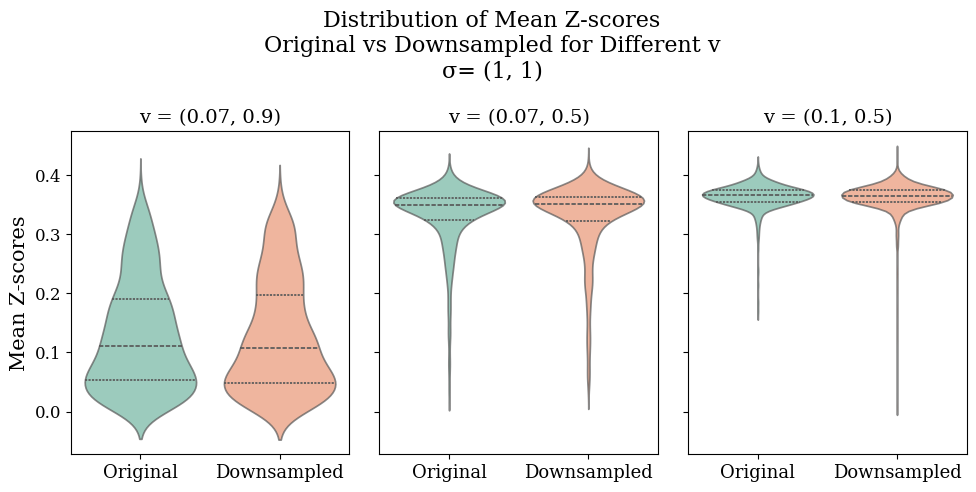

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
sns.violinplot(
    x = 'Dataset',
    y='Mean Z-scores', 
    hue='Dataset', 
    data=df, 
    inner='quartile',
    palette='Set2',
    density_norm='count', # scale the width of the violins by the number of observations in each category
    alpha = 0.7,
    ax=axes[0]
)

axes[0].set_ylabel('Mean Z-scores', fontsize=15)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelsize=13)
axes[0].set_title(f'v = (0.07, 0.9)', fontsize=14)

sns.violinplot(
    x = 'Dataset',
    y='Mean Z-scores', 
    hue='Dataset', 
    data=df_05, 
    inner='quartile',
    palette='Set2',
    density_norm='count', # scale the width of the violins by the number of observations in each category
    alpha = 0.7,
    ax=axes[1]
)

axes[1].set_title(f'v = (0.07, 0.5)', fontsize=14)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', labelsize=13)

sns.violinplot(
    x = 'Dataset',
    y='Mean Z-scores', 
    hue='Dataset', 
    data=df_0105, 
    inner='quartile',
    palette='Set2',
    density_norm='count', # scale the width of the violins by the number of observations in each category
    alpha = 0.7,
    ax=axes[2]
)

axes[2].set_title(f'v = (0.1, 0.5)', fontsize=14)
axes[2].tick_params(axis='y', labelsize=12)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', labelsize=13)

plt.suptitle(f'Distribution of Mean Z-scores\nOriginal vs Downsampled for Different v\nσ= {params["sigma_range"]}', fontsize=16)

plt.tight_layout()
plt.savefig(f'50seed_zscore_comparison_(1,1)_violin_subplot_{params["vol_param"]}_{params["rho_vol"]}.jpg', dpi=300)
plt.savefig(f'50seed_zscore_comparison_(1,1)_violin_subplot_{params["vol_param"]}_{params["rho_vol"]}.pdf', dpi=300)
plt.show()

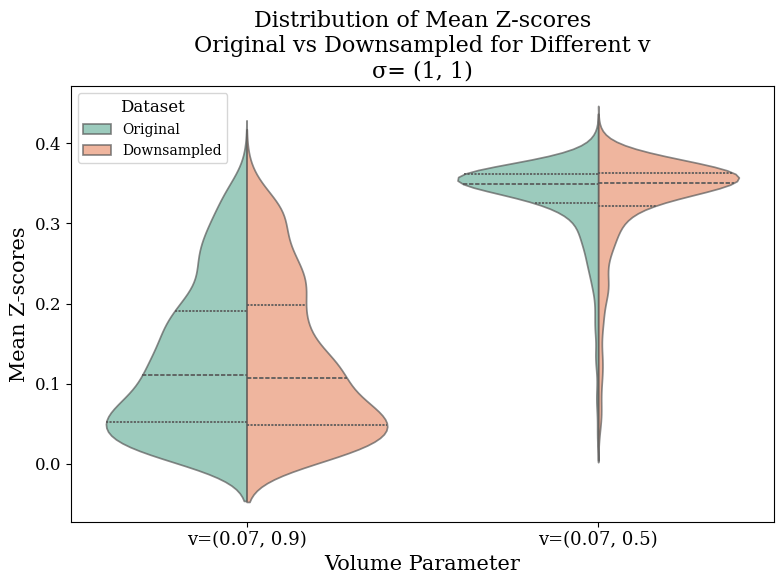

In [175]:
df = pd.DataFrame({
    'Mean Z-scores': np.concatenate([all_scores_orig_flat, all_scores_flat, all_scores_orig_05_flat, all_scores_05_flat]),
    'Dataset': ['Original'] * len(all_scores_orig_flat) + ['Downsampled'] * len(all_scores_flat) + ['Original'] * len(all_scores_orig_05_flat) + ['Downsampled'] * len(all_scores_05_flat),
    'Sigma': ['v=(0.07, 0.9)'] * (len(all_scores_orig_flat) + len(all_scores_flat)) + ['v=(0.07, 0.5)'] * (len(all_scores_orig_05_flat) + len(all_scores_05_flat))
})

plt.figure(figsize=(8, 6))
ax = sns.violinplot(
    x='Sigma',
    y='Mean Z-scores', 
    hue='Dataset', 
    data=df, 
    order=['v=(0.07, 0.9)', 'v=(0.07, 0.5)'],
    hue_order=['Original', 'Downsampled'],
    split=True,
    inner='quartile',
    palette='Set2',
    density_norm= 'count', # width is proportional to number of observations in each category
    alpha=0.7,
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['v=(0.07, 0.9)', 'v=(0.07, 0.5)'])
plt.ylabel('Mean Z-scores',fontsize=15)
plt.xlabel('Volume Parameter',fontsize=15)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=13)
plt.title(f'Distribution of Mean Z-scores\nOriginal vs Downsampled for Different v\nσ= {params["sigma_range"]}', fontsize=16)
plt.tight_layout()
plt.savefig(f'50seed_zscore_comparison_violin_{params["sigma_range"]}.jpg', dpi=300)
plt.savefig(f'50seed_zscore_comparison_violin_{params["sigma_range"]}.pdf', dpi=300)
plt.show()

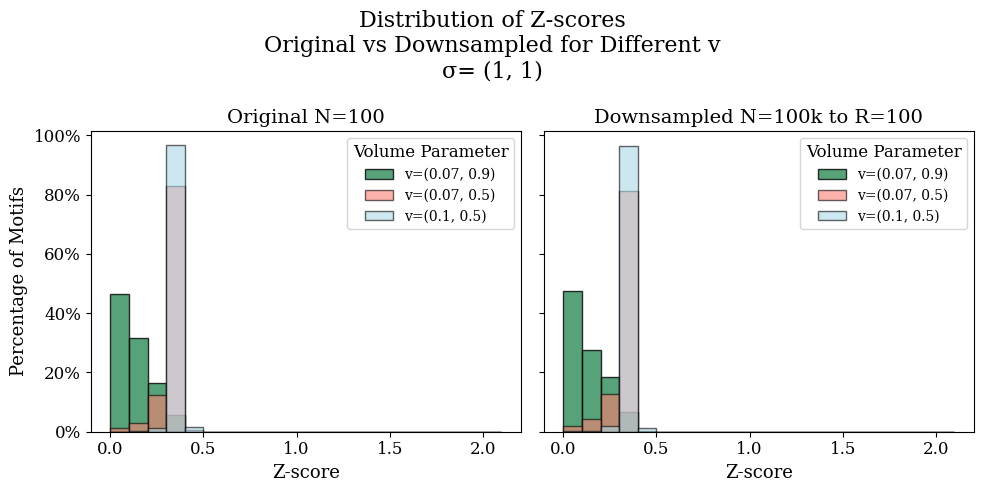

In [190]:
# This ensures a bin of 0.2 units is physically the same size in both plots
bin_edges = np.arange(0, 2.2, 0.1) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

weights_a = np.ones_like(all_scores_orig_flat) / len(all_scores_orig_flat)
weights_b = np.ones_like(all_scores_flat) / len(all_scores_flat)

weights_a_05 = np.ones_like(all_scores_orig_05_flat) / len(all_scores_orig_05_flat)
weights_b_05 = np.ones_like(all_scores_05_flat) / len(all_scores_05_flat)

weights_a_0105 = np.ones_like(all_scores_orig_0105_flat) / len(all_scores_orig_0105_flat)
weights_b_0105 = np.ones_like(all_scores_0105_flat) / len(all_scores_0105_flat)


# Format y-axis as percentage
from matplotlib.ticker import PercentFormatter
ax1.yaxis.set_major_formatter(PercentFormatter(1))

ax1.hist(all_scores_orig_flat, bins=bin_edges, weights=weights_a, color='seagreen', edgecolor='black', alpha=0.8, label='v=(0.07, 0.9)')
ax1.hist(all_scores_orig_05_flat, bins=bin_edges, weights=weights_a_05, color='salmon', edgecolor='black', alpha=0.6, label='v=(0.07, 0.5)')
ax1.hist(all_scores_orig_0105_flat, bins=bin_edges, weights=weights_a_0105, color='lightblue', edgecolor='black', alpha=0.6, label='v=(0.1, 0.5)')
ax2.hist(all_scores_flat, bins=bin_edges, weights=weights_b, color='seagreen', edgecolor='black', alpha=0.8, label='v=(0.07, 0.9)')
ax2.hist(all_scores_05_flat, bins=bin_edges, weights=weights_b_05, color='salmon', edgecolor='black', alpha=0.6, label='v=(0.07, 0.5)')
ax2.hist(all_scores_0105_flat, bins=bin_edges, weights=weights_b_0105, color='lightblue', edgecolor='black', alpha=0.6, label='v=(0.1, 0.5)')
ax1.set_title(f'Original N=100', fontsize=14)
ax1.set_xlabel('Z-score', fontsize=13)
ax1.set_ylabel('Percentage of Motifs', fontsize=13)
ax1.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)
ax1.legend(title='Volume Parameter')
ax2.set_title(f'Downsampled N=100k to R=100', fontsize=14)
ax2.set_xlabel('Z-score', fontsize=13)
ax2.legend(title='Volume Parameter')
plt.suptitle(f'Distribution of Z-scores\nOriginal vs Downsampled for Different v\nσ= {params["sigma_range"]}', fontsize=16)
plt.tight_layout()
plt.savefig(f'50seed_zscore_comparison_histogram_{params["sigma_range"]}.jpg', dpi=300)
plt.savefig(f'50seed_zscore_comparison_histogram_{params["sigma_range"]}.pdf', dpi=300)
plt.show()

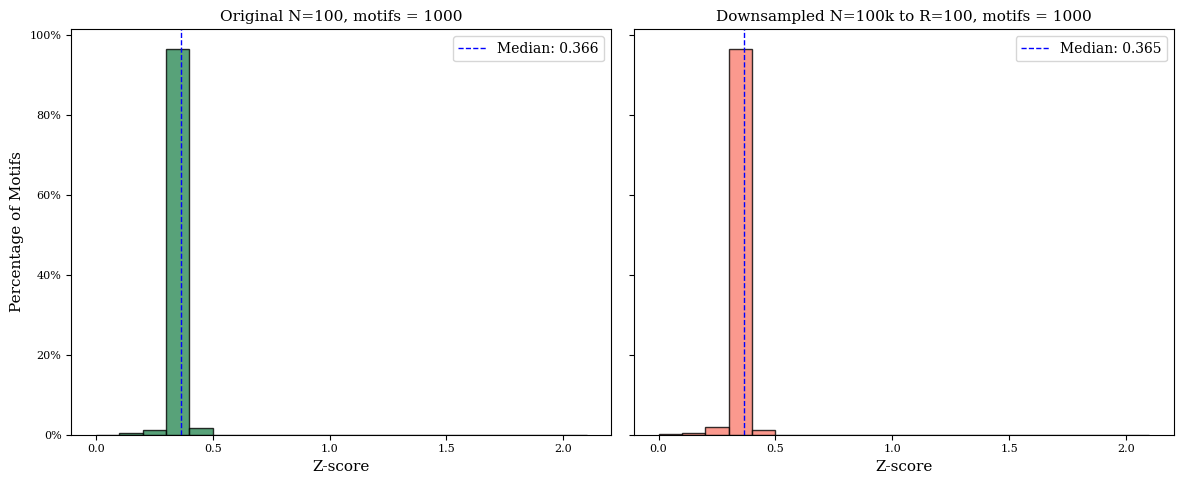

In [191]:
# This ensures a bin of 0.2 units is physically the same size in both plots
bin_edges = np.arange(0, 2.2, 0.1) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

weights_a = np.ones_like(all_scores_orig_0105_flat) / len(all_scores_orig_0105_flat)
weights_b = np.ones_like(all_scores_0105_flat) / len(all_scores_0105_flat)
motifs = {len(all_scores_flat)}

# Format y-axis as percentage
from matplotlib.ticker import PercentFormatter
ax1.yaxis.set_major_formatter(PercentFormatter(1))

ax1.hist(all_scores_orig_0105_flat, bins=bin_edges, weights=weights_a, color='seagreen', edgecolor='black', alpha=0.8)
ax2.hist(all_scores_0105_flat, bins=bin_edges, weights=weights_b, color='salmon', edgecolor='black', alpha=0.8)
ax1.axvline(x=np.median(all_scores_orig_0105_flat), color='blue', linestyle='--', label=f'Median: {np.median(all_scores_orig_0105_flat):.3f}')
ax2.axvline(x=np.median(all_scores_0105_flat), color='blue', linestyle='--', label=f'Median: {np.median(all_scores_0105_flat):.3f}')

ax1.set_title(f'Original N=100, motifs = {len(all_scores_orig_05_flat)}')
ax1.set_xlabel('Z-score')
ax1.set_ylabel('Percentage of Motifs')
ax1.legend()
ax2.set_title(f'Downsampled N=100k to R=100, motifs = {len(all_scores_flat)}')
ax2.set_xlabel('Z-score')
ax2.legend()

plt.tight_layout()
plt.show()